# Expert Agent RL

A PPO algorithm is trained on reduced action space obtained using expert knowledge. The reduced action space could be obtained using the scripts provided in `utils` module.

## How to install

## How to install

Create a virtual environment
```bash
conda create -n expert_agent python=3.10
conda activate venv_gnn
```

Clone and install the LJN agent (javaness winning solution adapted for the following scenario):

```bash
git clone git@github.com:Mleyliabadi/l2rpn-2023-ljn-agent.git
cd l2rpn-2023-ljn-agent
pip install -U .
```

Then clone this repository and install the dependencies:

```bash
git clone git@github.com:AI4REALNET/T2.1_deep_expert.git
pip install -U .
```

You should also install l2rpn_baselines package
```bash
pip install l2rpn_baselines
```

In [1]:
import os
import argparse
import numpy as np

from LJNAgent.modules.rewards import PPO_Reward
from LJNAgent.modules.rewards import MaxRhoReward
from stable_baselines3.ppo import MlpPolicy
from grid2op.Runner import Runner


from ExpertAgent.ExpertAgent import ExpertAgentRL
from ExpertAgent.utils.helper_functions import create_env
from ExpertAgent.utils import get_package_root
from ExpertAgent.utils.helper_functions import plot_runner_results

2026-02-15 23:42:45.160245: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 23:42:45.280277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 23:42:47.485748: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Create an environment with reduced action space

In [2]:
env_name = "ai4realnet_small"
reward_class = PPO_Reward # LinesCapacityReward
reward_class = MaxRhoReward
seed = 12345
obs_attr_to_keep = ["rho"]
act_attr_to_keep = ["set_bus"]

env, env_gym = create_env(env_name=env_name,
                          reward_class=reward_class,
                          obs_attr_to_keep=obs_attr_to_keep,
                          action_space_path="read_from_file"
                          )
env.seed(seed)
obs = env.reset()

### Agent parameters and hyperparameters

For evaluation, we load an already trained agent

In [19]:
# Agent parameters
name = "PPO_SB3"
load_path = os.path.join(get_package_root(), "..", name, "model", "PPO_SB3")
logs_dir = None

net_arch=[800, 1000, 1000, 800]
policy_kwargs = {}
policy_kwargs["net_arch"] = net_arch

nn_kwargs = {
        "policy": MlpPolicy,
        "env": env_gym,
        "verbose": True,
        "learning_rate": 3e-4,
        "tensorboard_log": logs_dir,
        "policy_kwargs": policy_kwargs,
        "device": "auto"
    }

In [20]:
agent = ExpertAgentRL(name="PPO_SB3",
                      env=env,
                      action_space=env.action_space,
                      gymenv=env_gym,
                      gym_act_space=env_gym.action_space,
                      gym_obs_space=env_gym.observation_space,
                      nn_kwargs=nn_kwargs
                      )

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Load the agent from the path

In [21]:
agent.load(load_path)

### Evaluation using Runner

In [22]:
seeds = np.arange(15)
runner_params = env.get_params_for_runner()
runner_params["verbose"] = True

max_steps = env.chronics_handler.max_episode_duration()

logs_path = "./logs-eval"
if logs_path is not None:
    os.makedirs(logs_path, exist_ok=True)

runner = Runner(**runner_params, 
                agentClass=None, 
                agentInstance=agent)

In [23]:
results = runner.run(path_save=logs_path,
                     nb_episode=15,
                     nb_process=1,
                     max_iter=max_steps,
                     pbar=True,
                     env_seeds=seeds
                    )

episode: 100%|██████████| 15/15 [02:37<00:00, 10.51s/it]


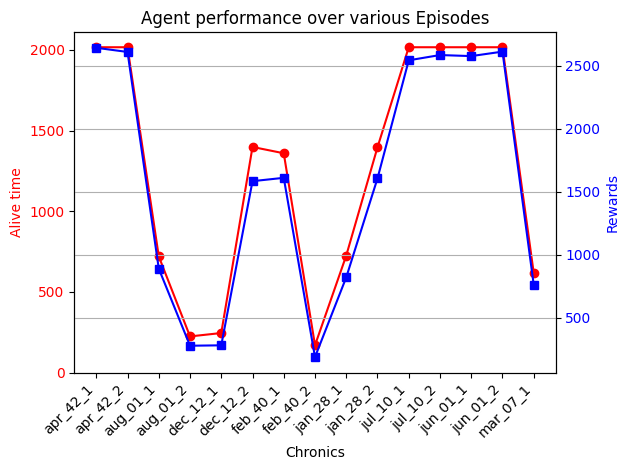

In [24]:
plot_runner_results(results, max_steps)